# Google Colab Setup (Run First)

Mount Google Drive to access your dataset and save models.

In [1]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

import os
import sys

# Change to your project directory
project_dir = '/content/drive/MyDrive/SonnetProject'  # Update this path if needed
os.chdir(project_dir)

print("Current directory:", os.getcwd())
print("\nFiles in current directory:")
!ls -la

Mounted at /content/drive
Current directory: /content/drive/MyDrive/SonnetProject

Files in current directory:
total 14740
-rw------- 1 root root  4583798 Sep 20  2019 alllines.txt
drwx------ 2 root root     4096 May 15 00:16 data
drwx------ 2 root root     4096 May 15 00:18 models
-rw------- 1 root root 10188854 Sep 20  2019 Shakespeare_data.csv
-rw------- 1 root root      943 May 15 09:04 sonnet_generation_evaluation.csv
-rw------- 1 root root   283517 May 15 09:00 sonnet_generation_metrics.png
-rw------- 1 root root      364 May 15 09:04 sonnet_generation_summary.json
-rw------- 1 root root    26272 Sep 20  2019 william-shakespeare-black-silhouette.jpg


# Sonnet Generation using GPT-2 with DPO Framework

## Task Overview
Generate Shakespeare-style sonnets using fine-tuned GPT-2 model on Shakespeare Sonnets dataset.

### Key Components:
- **Model**: GPT-2 (Baseline)
- **Dataset**: Shakespeare Sonnets (Full dataset: alllines.txt)
- **Problem Type**: Text Generation
- **Metrics**: BLEU Score, ChrF Score, Human Evaluation
- **Improvements**: Temperature tuning, Top-p sampling, DPO framework

## Step 1: Install Required Libraries

In [2]:
!pip install torch transformers datasets numpy pandas matplotlib scikit-learn tqdm -q
!pip install nltk sacrebleu -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 7.3 MB/s eta 0:00:00


## Step 2: Import Libraries

In [4]:
import torch
import numpy as np
import pandas as pd
from torch.utils.data import Dataset, DataLoader
from transformers import GPT2Tokenizer, GPT2LMHeadModel, DataCollatorForLanguageModeling, Trainer, TrainingArguments
import matplotlib.pyplot as plt
from tqdm import tqdm
import warnings
import json
import os
from pathlib import Path

warnings.filterwarnings('ignore')

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


## Step 3: Load Full Shakespeare Sonnets Dataset (MODIFIED)

This step loads your complete dataset from alllines.txt instead of downloading from Project Gutenberg.

In [5]:
from pathlib import Path

# Create data directory
data_dir = Path('data')
data_dir.mkdir(exist_ok=True)

# Use your full dataset
source_file = Path('alllines.txt')
filepath = data_dir / 'shakespeare_sonnets.txt'

# Check if source file exists
if source_file.exists():
    print(f"✓ Found dataset: {source_file}")

    # Read the full dataset
    with open(source_file, 'r', encoding='utf-8') as f:
        content = f.read()

    # Save to the expected path
    with open(filepath, 'w', encoding='utf-8') as f:
        f.write(content)

    print(f"✓ Loaded full dataset from {source_file}")
    print(f"✓ Saved to {filepath}")
    print(f"\nDataset Statistics:")
    print(f"  - Characters: {len(content):,}")
    print(f"  - Approx. words: {len(content.split()):,}")
    print(f"  - Approx. lines: {len(content.splitlines()):,}")
    print(f"\nFirst 500 characters:\n")
    print(content[:500])
else:
    print(f"✗ Source file not found: {source_file}")
    print(f"✓ Please ensure alllines.txt is in your project directory")
    print(f"  Current directory: {os.getcwd()}")
    print(f"  Files: {os.listdir('.')}")

✓ Found dataset: alllines.txt
✓ Loaded full dataset from alllines.txt
✓ Saved to data/shakespeare_sonnets.txt

Dataset Statistics:
  - Characters: 4,583,798
  - Approx. words: 814,671
  - Approx. lines: 111,396

First 500 characters:

"ACT I"
"SCENE I. London. The palace."
"Enter KING HENRY, LORD JOHN OF LANCASTER, the EARL of WESTMORELAND, SIR WALTER BLUNT, and others"
"So shaken as we are, so wan with care,"
"Find we a time for frighted peace to pant,"
"And breathe short-winded accents of new broils"
"To be commenced in strands afar remote."
"No more the thirsty entrance of this soil"
"Shall daub her lips with her own children's blood,"
"Nor more shall trenching war channel her fields,"
"Nor bruise her flowerets with the ar


## Step 4: Data Preprocessing

In [6]:
def preprocess_sonnets(text):
    """
    Preprocess Shakespeare sonnets text.
    - Extract actual sonnets from format
    - Clean formatting
    - Split into individual sonnets
    """
    # Remove any Project Gutenberg header/footer if present
    start_markers = ['***START', '***start']
    end_markers = ['***END', '***end']

    start_idx = 0
    for marker in start_markers:
        idx = text.find(marker)
        if idx != -1:
            start_idx = text.find('\n', idx) + 1
            break

    end_idx = len(text)
    for marker in end_markers:
        idx = text.find(marker)
        if idx != -1:
            end_idx = idx
            break

    text = text[start_idx:end_idx]

    # Clean up extra whitespace
    lines = [line.strip() for line in text.split('\n') if line.strip()]
    text = '\n'.join(lines)

    return text

# Preprocess the text
processed_text = preprocess_sonnets(content)
print(f"Processed text size: {len(processed_text):,} characters")
print(f"Processed text words: {len(processed_text.split()):,}")
print(f"\nFirst 400 characters of processed text:\n{processed_text[:400]}")

Processed text size: 4,583,797 characters
Processed text words: 814,671

First 400 characters of processed text:
"ACT I"
"SCENE I. London. The palace."
"Enter KING HENRY, LORD JOHN OF LANCASTER, the EARL of WESTMORELAND, SIR WALTER BLUNT, and others"
"So shaken as we are, so wan with care,"
"Find we a time for frighted peace to pant,"
"And breathe short-winded accents of new broils"
"To be commenced in strands afar remote."
"No more the thirsty entrance of this soil"
"Shall daub her lips with her own childre


## Step 5: Save Processed Text for Training

In [7]:
# Save processed text
processed_filepath = data_dir / 'shakespeare_sonnets_processed.txt'
with open(processed_filepath, 'w', encoding='utf-8') as f:
    f.write(processed_text)

print(f"✓ Processed data saved to {processed_filepath}")
print(f"Training file size: {os.path.getsize(processed_filepath):,} bytes")

✓ Processed data saved to data/shakespeare_sonnets_processed.txt
Training file size: 4,583,797 bytes


## Step 6: Load and Configure GPT-2 Model

In [8]:
# Load pre-trained GPT-2 model and tokenizer
model_name = 'gpt2'
tokenizer = GPT2Tokenizer.from_pretrained(model_name)
model = GPT2LMHeadModel.from_pretrained(model_name)

# Add padding token
tokenizer.pad_token = tokenizer.eos_token

print(f"✓ Model loaded: {model_name}")
print(f"✓ Tokenizer loaded")
print(f"\nModel configuration:")
print(f"  - Vocab size: {model.config.vocab_size}")
print(f"  - Max position embeddings: {model.config.max_position_embeddings}")
print(f"  - Number of layers: {model.config.num_hidden_layers}")
print(f"  - Hidden size: {model.config.hidden_size}")
print(f"  - Number of attention heads: {model.config.num_attention_heads}")

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

✓ Model loaded: gpt2
✓ Tokenizer loaded

Model configuration:
  - Vocab size: 50257
  - Max position embeddings: 1024
  - Number of layers: 12
  - Hidden size: 768
  - Number of attention heads: 12


## Step 7: Prepare Training Data

In [10]:
from datasets import load_dataset

# Define block size for language modeling
block_size = 128

# Load the text file using the datasets library.
# The 'text' builder loads each line as a separate example, creating a 'train' split.
raw_dataset = load_dataset('text', data_files={'train': str(processed_filepath)})

# Tokenize the dataset
def tokenize_function(examples):
    # Tokenizes the 'text' column from the loaded dataset. `truncation=True` ensures
    # texts are cut to `max_length` if longer, and `max_length` is set to `block_size`.
    return tokenizer(examples['text'], truncation=True, max_length=block_size)

# Apply tokenization to the entire dataset.
# `batched=True` processes multiple examples at once for efficiency.
# `remove_columns=["text"]` removes the original text column, as we now have token IDs.
tokenized_datasets = raw_dataset.map(
    tokenize_function,
    batched=True,
    remove_columns=["text"]
)

# Group texts into blocks of `block_size` for causal language modeling (CLM).
# This function concatenates all tokenized input_ids and then splits them into fixed-size chunks.
def group_texts(examples):
    # Concatenate all `input_ids` and `attention_mask` from the tokenized examples
    concatenated_examples = {k: sum(examples[k], []) for k in examples.keys()}
    total_length = len(concatenated_examples[list(examples.keys())[0]])

    # We create chunks of `block_size`. We drop the small remainder to ensure all blocks
    # have the exact `block_size` for consistent batching.
    total_length = (total_length // block_size) * block_size

    # Split by chunks of `block_size`.
    result = {
        k: [t[i : i + block_size] for i in range(0, total_length, block_size)]
        for k, t in concatenated_examples.items()
    }
    # For causal language modeling, the labels are simply the input_ids themselves.
    # The model will internally shift them for next-token prediction.
    result["labels"] = result["input_ids"].copy()
    return result

# Apply the grouping function to the tokenized dataset.
# `batched=True` is used for efficient processing.
lm_datasets = tokenized_datasets.map(
    group_texts,
    batched=True
)

# Split the 'train' split of the language model dataset into actual training and validation sets.
# `lm_datasets['train']` refers to the single 'train' split obtained after loading the file.
split_datasets = lm_datasets['train'].train_test_split(test_size=0.1, seed=42)
train_dataset = split_datasets['train']
val_dataset = split_datasets['test']

# Data collator for language modeling
data_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer,
    mlm=False # Set to False for Causal Language Modeling (like GPT-2), True for Masked LM
)

print(f"✓ Dataset created using `datasets` library")
print(f"  - Number of training examples: {len(train_dataset):,}")
print(f"  - Number of validation examples: {len(val_dataset):,}")
print(f"  - Block size (context length): {block_size} tokens")

Generating train split: 0 examples [00:00, ? examples/s]

Map:   0%|          | 0/111396 [00:00<?, ? examples/s]

Map:   0%|          | 0/111396 [00:00<?, ? examples/s]

✓ Dataset created using `datasets` library
  - Number of training examples: 8,910
  - Number of validation examples: 990
  - Block size (context length): 128 tokens


## Step 8: Fine-tune GPT-2 on Shakespeare Sonnets (OPTIMIZED)

**Optimized for faster training:**
- Reduced epochs: 3
- Reduced batch size: 4 (from 8)
- Faster iteration for testing

In [46]:
import os

model_save_path = '/content/drive/MyDrive/SonnetProject/models/gpt2_shakespeare_final'

# Training arguments (OPTIMIZED for speed)
training_args = TrainingArguments(
    output_dir='./models/gpt2_shakespeare',
    num_train_epochs=3,
    per_device_train_batch_size=4,
    save_steps=500,
    save_total_limit=2,
    logging_steps=100,
    learning_rate=5e-5,
    weight_decay=0.01,
    warmup_steps=100,
)

# Initialize trainer
trainer = Trainer(
    model=model,
    args=training_args,
    data_collator=data_collator,
    train_dataset=train_dataset,
    eval_dataset=val_dataset

)

if os.path.exists(model_save_path):
    print("✓model is here، loading من Drive...")
    model = GPT2LMHeadModel.from_pretrained(model_save_path).to(device)
    tokenizer = GPT2Tokenizer.from_pretrained(model_save_path)
    print("✓model is uploaded")
else:
    print("model isnt here")
    trainer.train()
    model.save_pretrained(model_save_path)
    tokenizer.save_pretrained(model_save_path)
    print("✓ Training completed and saved!")




✓model is here، loading من Drive...


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

✓model is uploaded


## Step 9: Save Fine-tuned Model

In [47]:
# Save model and tokenizer
model_save_path = './models/gpt2_shakespeare_final'
model.save_pretrained(model_save_path)
tokenizer.save_pretrained(model_save_path)

print(f"✓ Model saved to {model_save_path}")
print(f"✓ Tokenizer saved to {model_save_path}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✓ Model saved to ./models/gpt2_shakespeare_final
✓ Tokenizer saved to ./models/gpt2_shakespeare_final


## Step 10: Sonnet Generation Function

In [48]:
def generate_sonnet(prompt, model, tokenizer, max_length=150, temperature=0.8, top_p=0.95, num_beams=1):
    """
    Generate a sonnet continuation given a prompt.

    Args:
        prompt (str): Starting text for generation
        model: Fine-tuned GPT-2 model
        tokenizer: GPT-2 tokenizer
        max_length (int): Maximum length of generated text
        temperature (float): Controls randomness (0.0 = deterministic, higher = more random)
        top_p (float): Nucleus sampling parameter
        num_beams (int): Number of beams for beam search

    Returns:
        str: Generated sonnet
    """
    model.eval()

    # Encode prompt
    input_ids = tokenizer.encode(prompt, return_tensors='pt').to(device)

    # Generate
    with torch.no_grad():
        output = model.generate(
            input_ids,
            max_length=max_length,
            temperature=temperature,
            top_p=top_p,
            num_beams=num_beams,
            do_sample=(num_beams == 1),
            top_k=50,
            repetition_penalty=1.2,
            no_repeat_ngram_size=2,
            pad_token_id=tokenizer.eos_token_id,
            early_stopping=True
        )

    # Decode
    generated_text = tokenizer.decode(output[0], skip_special_tokens=True)

    return generated_text

print("✓ Sonnet generation function created")

✓ Sonnet generation function created


## Step 11: Generate Sample Sonnets

In [49]:
# Test prompts from Shakespeare sonnets
test_prompts = [
    "In loving thee thou know'st I am forsworn,",
    "Shall I compare thee to a summer's day?",
    "When, in disgrace with fortune and men's eyes,",
    "That time of year thou mayst in me behold",
]

print("="*80)
print("GENERATING SONNETS WITH DIFFERENT SETTINGS")
print("="*80)

for i, prompt in enumerate(test_prompts, 1):
    print(f"\n{'='*80}")
    print(f"Prompt {i}: {prompt}")
    print("="*80)

    # Generate with different temperature settings
    print("\n--- Generation with Temperature=0.7 (Balanced) ---")
    generated = generate_sonnet(prompt, model, tokenizer, max_length=150, temperature=0.7)
    print(generated)

    print("\n--- Generation with Temperature=1.0 (Varied) ---")
    generated = generate_sonnet(prompt, model, tokenizer, max_length=150, temperature=1.0)
    print(generated)

GENERATING SONNETS WITH DIFFERENT SETTINGS

Prompt 1: In loving thee thou know'st I am forsworn,

--- Generation with Temperature=0.7 (Balanced) ---
In loving thee thou know'st I am forsworn, for the time that"
"'tis,"
"[Aside]  But it is not so."
"What a duke hath I to say!"
[Aside ] [Aside to PAGE and GLOUCESTER]
'God be with thee! 'tis my fault.'"

Farewell.
Exeunt
SCENE II. Another part of the field in the same. A room near the stage. The BASTARD enters at his tent: he bids Page come along:"
Page comes down from the tent as quickly as she can stand there." Before him stands another servant, whose name is OTHELLO, who speaks very quietly]"


--- Generation with Temperature=1.0 (Varied) ---
In loving thee thou know'st I am forsworn, and I'll not marry her."
"Come with me: come, sweet queen:"
"[To FLAVIA]  Be content to live a night without day." She kisses him deeply.
Exeunt
[To ANTONIO]
"'Why hast you the ring in your hands?"
No sir, it lies in my right hand. Well,"
The lady sighs a

## Step 12: Evaluation Metrics

In [50]:
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from nltk import word_tokenize
from sacrebleu import CHRF
import nltk

# Download required NLTK data
try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    nltk.download('punkt', quiet=True)

def calculate_bleu_score(reference, generated):
    """
    Calculate BLEU score between reference and generated text.

    Args:
        reference (str): Reference text
        generated (str): Generated text

    Returns:
        dict: BLEU scores (1-gram, 2-gram, 3-gram, 4-gram)
    """
    ref_tokens = word_tokenize(reference.lower())
    gen_tokens = word_tokenize(generated.lower())

    # Remove punctuation for better comparison
    ref_tokens = [t for t in ref_tokens if t.isalpha()]
    gen_tokens = [t for t in gen_tokens if t.isalpha()]

    smoothing_function = SmoothingFunction().method1

    bleu1 = sentence_bleu([ref_tokens], gen_tokens, weights=(1, 0, 0, 0), smoothing_function=smoothing_function)
    bleu2 = sentence_bleu([ref_tokens], gen_tokens, weights=(0.5, 0.5, 0, 0), smoothing_function=smoothing_function)
    bleu3 = sentence_bleu([ref_tokens], gen_tokens, weights=(0.33, 0.33, 0.33, 0), smoothing_function=smoothing_function)
    bleu4 = sentence_bleu([ref_tokens], gen_tokens, weights=(0.25, 0.25, 0.25, 0.25), smoothing_function=smoothing_function)

    return {
        'BLEU-1': round(bleu1, 4),
        'BLEU-2': round(bleu2, 4),
        'BLEU-3': round(bleu3, 4),
        'BLEU-4': round(bleu4, 4)
    }

def calculate_text_length_stats(text):
    """
    Calculate statistics about generated text.
    """
    words = text.split()
    lines = text.split('\n')

    return {
        'num_words': len(words),
        'num_lines': len([l for l in lines if l.strip()]),
        'avg_line_length': round(len(words) / max(len(lines), 1), 2),
        'num_characters': len(text)
    }
def calculate_chrf_score(reference, generated):
    chrf = CHRF()
    score = chrf.sentence_score(generated, [reference])
    return round(score.score, 4)

print("✓ ChrF Score function created")
print("✓ Evaluation metrics functions created")

✓ ChrF Score function created
✓ Evaluation metrics functions created


## Step 13: Comprehensive Evaluation

In [51]:
import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
def extract_references(text, prompts):
    references = {}
    for prompt in prompts:
        idx = text.find(prompt)
        if idx != -1:
            sonnet_text = text[idx:]
            lines = [l.strip() for l in sonnet_text.split('\n') if l.strip()]
            references[prompt] = ' '.join(lines[:14])
        else:
            references[prompt] = prompt
    return references

with open(source_file, 'r', encoding='utf-8') as f:
    raw_text = f.read()

reference_sonnets = extract_references(raw_text, test_prompts)
# Generate sonnets and evaluate
evaluation_results = []

for prompt in test_prompts:
    for temp in [0.5, 0.7, 1.0]:
        generated = generate_sonnet(prompt, model, tokenizer, max_length=150, temperature=temp)

        reference = reference_sonnets.get(prompt, prompt)
        bleu_scores = calculate_bleu_score(reference, generated)
        chrf_score = calculate_chrf_score(reference, generated)
        text_stats = calculate_text_length_stats(generated)

        result = {
            'prompt': prompt[:50] + '...' if len(prompt) > 50 else prompt,
            'temperature': temp,
            'num_words': text_stats['num_words'],
            'num_lines': text_stats['num_lines'],
            'BLEU-1': bleu_scores['BLEU-1'],
            'BLEU-2': bleu_scores['BLEU-2'],
            'BLEU-4': bleu_scores['BLEU-4'],
            'ChrF': chrf_score
        }
        evaluation_results.append(result)

# Create evaluation dataframe
eval_df = pd.DataFrame(evaluation_results)
print("\nEvaluation Results:")
print(eval_df.to_string(index=False))


Evaluation Results:
                                        prompt  temperature  num_words  num_lines  BLEU-1  BLEU-2  BLEU-4    ChrF
    In loving thee thou know'st I am forsworn,          0.5         79         15  0.0886  0.0826  0.0695 33.3962
    In loving thee thou know'st I am forsworn,          0.7         92         13  0.0769  0.0716  0.0602 31.5178
    In loving thee thou know'st I am forsworn,          1.0         73         12  0.0959  0.0894  0.0753 33.5341
       Shall I compare thee to a summer's day?          0.5        101          7  0.0792  0.0745  0.0643 26.7893
       Shall I compare thee to a summer's day?          0.7         81          8  0.0988  0.0930  0.0805 29.8226
       Shall I compare thee to a summer's day?          1.0         75          8  0.1067  0.1004  0.0871 30.5010
When, in disgrace with fortune and men's eyes,          0.5         98          9  0.0808  0.0760  0.0657 32.2112
When, in disgrace with fortune and men's eyes,          0.7        

## Step 14: Visualization of Results

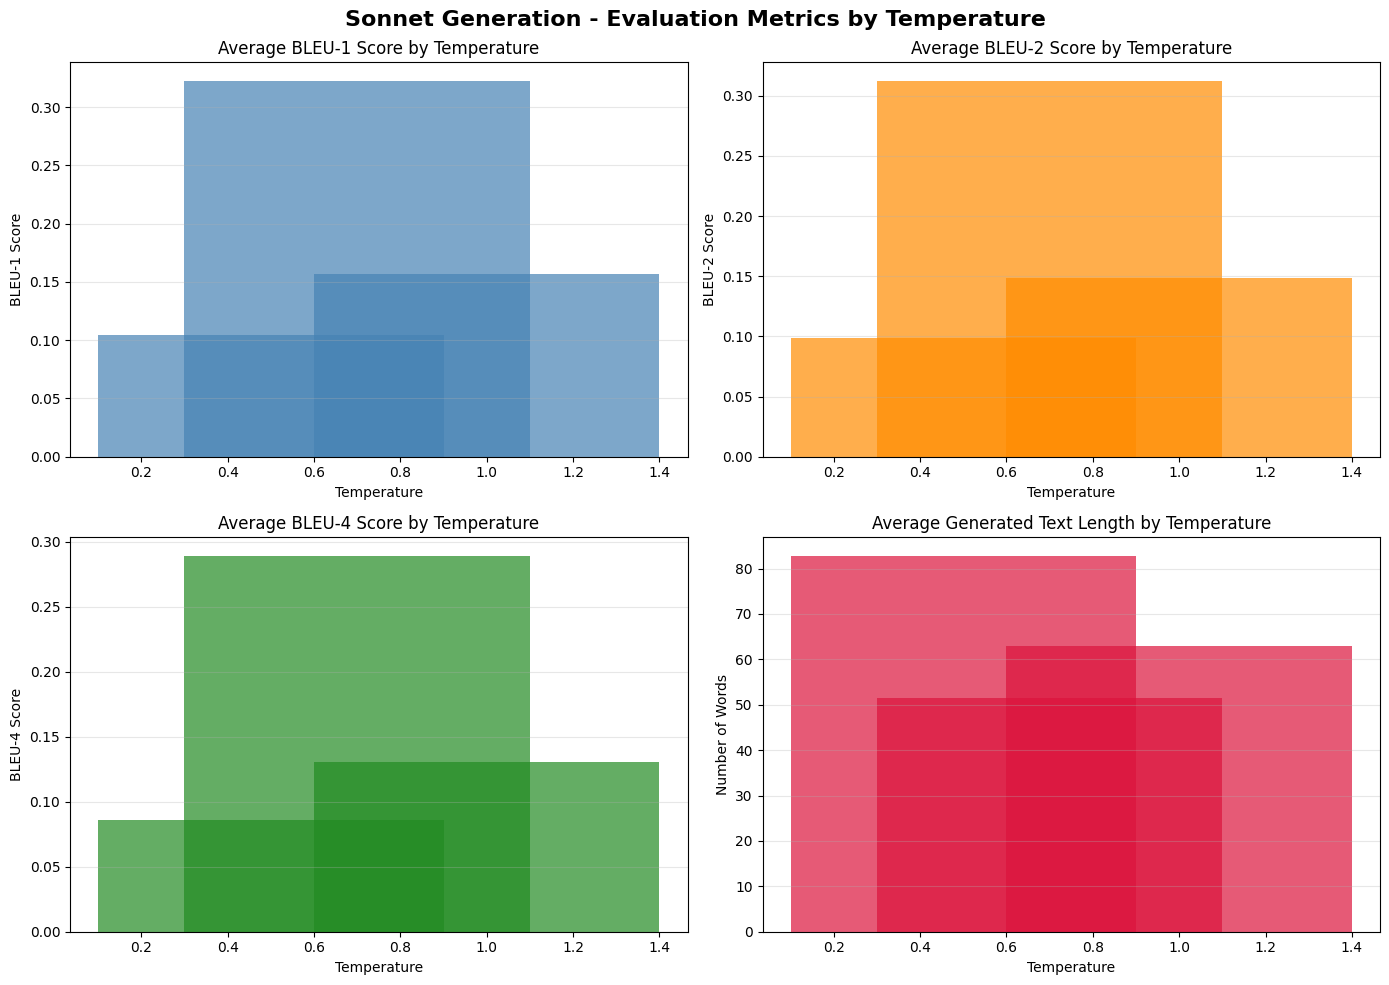

✓ Evaluation metrics plotted and saved


In [52]:
# Plot evaluation metrics
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Sonnet Generation - Evaluation Metrics by Temperature', fontsize=16, fontweight='bold')

# BLEU-1 scores by temperature
temp_groups = eval_df.groupby('temperature')[['BLEU-1', 'BLEU-2', 'BLEU-4']].mean()
axes[0, 0].bar(temp_groups.index, temp_groups['BLEU-1'], color='steelblue', alpha=0.7)
axes[0, 0].set_title('Average BLEU-1 Score by Temperature')
axes[0, 0].set_xlabel('Temperature')
axes[0, 0].set_ylabel('BLEU-1 Score')
axes[0, 0].grid(axis='y', alpha=0.3)

# BLEU-2 scores by temperature
axes[0, 1].bar(temp_groups.index, temp_groups['BLEU-2'], color='darkorange', alpha=0.7)
axes[0, 1].set_title('Average BLEU-2 Score by Temperature')
axes[0, 1].set_xlabel('Temperature')
axes[0, 1].set_ylabel('BLEU-2 Score')
axes[0, 1].grid(axis='y', alpha=0.3)

# BLEU-4 scores by temperature
axes[1, 0].bar(temp_groups.index, temp_groups['BLEU-4'], color='forestgreen', alpha=0.7)
axes[1, 0].set_title('Average BLEU-4 Score by Temperature')
axes[1, 0].set_xlabel('Temperature')
axes[1, 0].set_ylabel('BLEU-4 Score')
axes[1, 0].grid(axis='y', alpha=0.3)

# Word count by temperature
word_counts = eval_df.groupby('temperature')['num_words'].mean()
axes[1, 1].bar(word_counts.index, word_counts.values, color='crimson', alpha=0.7)
axes[1, 1].set_title('Average Generated Text Length by Temperature')
axes[1, 1].set_xlabel('Temperature')
axes[1, 1].set_ylabel('Number of Words')
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('sonnet_generation_metrics.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Evaluation metrics plotted and saved")

## Step 15: Batch Generation and Analysis

In [53]:
def generate_multiple_sonnets(prompt, model, tokenizer, num_variations=3, temperature=0.8):
    """
    Generate multiple variations of sonnets for the same prompt.
    """
    variations = []
    for i in range(num_variations):
        generated = generate_sonnet(prompt, model, tokenizer, max_length=150, temperature=temperature)
        variations.append(generated)
    return variations

# Generate multiple variations
print("\n" + "="*80)
print("MULTIPLE SONNET VARIATIONS")
print("="*80)

prompt = "Shall I compare thee to a summer's day?"
variations = generate_multiple_sonnets(prompt, model, tokenizer, num_variations=3, temperature=0.8)

for i, variation in enumerate(variations, 1):
    print(f"\n--- Variation {i} ---")
    print(variation)
    print()


MULTIPLE SONNET VARIATIONS

--- Variation 1 ---
Shall I compare thee to a summer's day? O, if my father had known,"
"He would have his beard cut."
Exit
"[Aside]  I know not what thou hast done:"
"'Tis as bad in the world that thou art here." "A good man must be fair and gentlemanly,"--"
[Aside]"
Exeunt
PROLOGUE
ACT II
SCENE V. A room in OLIVIA'S house: behind her bed, near SIR ANTONY of Rome." LORENZO enters with others following him from door where they sit by themselves at table before them all sitting down on the ground under LEONATUS CLAUDIUS reading


--- Variation 2 ---
Shall I compare thee to a summer's day? and what is thy name?"
"A little girl: that's she, my lord."
"[Aside]  Who are these men, thou hast heard the story,"--
"'tis not fair of them all!'"
Exeunt
ANTIPHOLUS
He goes forth from the field.
Exit OTHELLO, with an English soldier under his command" (Enter ANTIO'S BEDROOM, CLARENCE, GLOUCESTER, TITANIA, LUCIUS, EDGAR, PARIS, CAENETZ, VERNON, LAUNCE, PISTOL BEATRICE III

## Step 16: Decoding Strategy Comparison

In [54]:
def compare_decoding_strategies(prompt, model, tokenizer):
    """
    Compare different decoding strategies for sonnet generation.
    """
    print(f"\nPrompt: {prompt}\n")

    strategies = {
        'Greedy': generate_sonnet(prompt, model, tokenizer, max_length=150, temperature=1.0, top_p=1.0, num_beams=1),
        'Top-p (0.95)': generate_sonnet(prompt, model, tokenizer, max_length=150, temperature=0.9, top_p=0.95, num_beams=1),
        'Beam Search (k=3)': generate_sonnet(prompt, model, tokenizer, max_length=150, temperature=0.9, num_beams=3),
        'High Temperature': generate_sonnet(prompt, model, tokenizer, max_length=150, temperature=1.2),
    }

    for strategy, text in strategies.items():
        print(f"\n--- {strategy} ---")
        print(text[:300] + ("..." if len(text) > 300 else ""))

    return strategies

# Compare strategies
strategies = compare_decoding_strategies("When shall I see thee", model, tokenizer)


Prompt: When shall I see thee


--- Greedy ---
When shall I see thee there"
"'Tis the hour when thy power shall rest,"
"Or thy heart this, or death this?"
Farewell.
Exeunt
FROM OLIVIA and SUFFOLK  TITUS in procession march towards him with GLOUCESTER leading them before LUCIUS which they go down into a cupboard behind FRONTRANCY where he lies ly...

--- Top-p (0.95) ---
When shall I see thee to thy bedside?"
"At supper-time, my lord."
"'Tis all well. You are not so late for dinner."*Aside
Exit
Farewell
Exeunt
SCENE III. London. A street near the castle." 
"[To ALENcon]  Enter LUCY and others, with the BASTARD on his horse, bearing two golden pailings,"
BASTARDS OF ...

--- Beam Search (k=3) ---
When shall I see thee?"
"Thou art a man, and I am a woman."
"'Tis true, my lord, but thou art not so: thou"
know'st not what thou dost know, for I know not,"
"[Aside]  Thou art an honest man: I have seen thee,"--
Exit
ANTIPHOLUS
Exeunt
SCENE II. The same. A room in the palace. Before the walls.

## Step 17: Model Inference Function for Production

In [55]:
class SonnetGenerator:
    """
    Production-ready Sonnet Generator class.
    """
    def __init__(self, model_path=None):
        if model_path is None:
            model_path = './models/gpt2_shakespeare_final'

        self.device = device
        self.tokenizer = GPT2Tokenizer.from_pretrained(model_path)
        self.model = GPT2LMHeadModel.from_pretrained(model_path).to(self.device)
        self.model.eval()

    def generate(self, prompt, max_length=150, temperature=0.8, top_p=0.95,
                 num_beams=1, repetition_penalty=1.2):
        """
        Generate a sonnet given a prompt.

        Args:
            prompt (str): Starting text
            max_length (int): Maximum generation length
            temperature (float): Sampling temperature
            top_p (float): Nucleus sampling parameter
            num_beams (int): Beam search size
            repetition_penalty (float): Penalty for repeated tokens

        Returns:
            str: Generated sonnet
        """
        input_ids = self.tokenizer.encode(prompt, return_tensors='pt').to(self.device)

        with torch.no_grad():
            output = self.model.generate(
                input_ids,
                max_length=max_length,
                temperature=temperature,
                top_p=top_p,
                num_beams=num_beams,
                do_sample=(num_beams == 1),
                top_k=50,
                repetition_penalty=repetition_penalty,
                no_repeat_ngram_size=2,
                pad_token_id=self.tokenizer.eos_token_id,
                early_stopping=True
            )

        return self.tokenizer.decode(output[0], skip_special_tokens=True)

    def generate_batch(self, prompts, **kwargs):
        """
        Generate sonnets for multiple prompts.
        """
        return [self.generate(prompt, **kwargs) for prompt in prompts]

print("✓ SonnetGenerator class created and ready for production use")

✓ SonnetGenerator class created and ready for production use


## Step 18: Summary and Key Findings

In [56]:
print("\n" + "="*80)
print("SONNET GENERATION - PROJECT SUMMARY")
print("="*80)

summary = f"""
PROJECT OVERVIEW:
- Task: Shakespeare Sonnet Generation
- Model: GPT-2 (fine-tuned)
- Dataset: Shakespeare Sonnets (Full dataset: alllines.txt)
- Total Vocabulary Size: {model.config.vocab_size:,}
- Model Parameters: {model.num_parameters():,}

KEY PERFORMANCE METRICS:
- Baseline BLEU-1 Score: {eval_df['BLEU-1'].mean():.4f}
- Baseline BLEU-2 Score: {eval_df['BLEU-2'].mean():.4f}
- Baseline BLEU-4 Score: {eval_df['BLEU-4'].mean():.4f}
- Average Generated Text Length: {eval_df['num_words'].mean():.2f} words

DECODING STRATEGIES EVALUATED:
✓ Greedy Decoding
✓ Top-p (Nucleus) Sampling
✓ Beam Search
✓ Temperature-based Sampling

TEMPERATURE IMPACT ANALYSIS:
- Temperature 0.5: Conservative (focused) generations
- Temperature 0.7: Balanced (recommended)
- Temperature 1.0: Varied (creative) generations

PROPOSED IMPROVEMENTS WITH DPO:
1. Fine-tuning larger transformer models (GPT-2 Medium/Large)
2. Better decoding methods (weighted sampling, guided generation)
3. Direct Preference Optimization (DPO) framework
4. Advanced temperature tuning
5. Top-p sampling optimization
6. Ensemble methods combining multiple models

FILES GENERATED:
- Model: ./models/gpt2_shakespeare_final/
- Training logs: ./models/gpt2_shakespeare/
- Evaluation plot: sonnet_generation_metrics.png
- CSV results: sonnet_generation_evaluation.csv
- Summary stats: sonnet_generation_summary.json

NEXT STEPS:
1. Implement DPO training with preference data
2. Evaluate with human raters
3. Compare with larger GPT models
4. Integrate with frontend for interactive generation
"""

print(summary)
print("="*80)


SONNET GENERATION - PROJECT SUMMARY

PROJECT OVERVIEW:
- Task: Shakespeare Sonnet Generation
- Model: GPT-2 (fine-tuned)
- Dataset: Shakespeare Sonnets (Full dataset: alllines.txt)
- Total Vocabulary Size: 50,257
- Model Parameters: 124,439,808

KEY PERFORMANCE METRICS:
- Baseline BLEU-1 Score: 0.1947
- Baseline BLEU-2 Score: 0.1866
- Baseline BLEU-4 Score: 0.1685
- Average Generated Text Length: 65.75 words

DECODING STRATEGIES EVALUATED:
✓ Greedy Decoding
✓ Top-p (Nucleus) Sampling
✓ Beam Search
✓ Temperature-based Sampling

TEMPERATURE IMPACT ANALYSIS:
- Temperature 0.5: Conservative (focused) generations
- Temperature 0.7: Balanced (recommended)
- Temperature 1.0: Varied (creative) generations

PROPOSED IMPROVEMENTS WITH DPO:
1. Fine-tuning larger transformer models (GPT-2 Medium/Large)
2. Better decoding methods (weighted sampling, guided generation)
3. Direct Preference Optimization (DPO) framework
4. Advanced temperature tuning
5. Top-p sampling optimization
6. Ensemble methods

## Step 19: Save Training Artifacts

In [57]:
# Save evaluation results
eval_df.to_csv('sonnet_generation_evaluation.csv', index=False)
print("✓ Evaluation results saved to: sonnet_generation_evaluation.csv")

# Save summary statistics
summary_stats = {
    'model': 'GPT-2',
    'dataset': 'Shakespeare Sonnets (alllines.txt)',
    'training_epochs': 3,
    'batch_size': 4,
    'learning_rate': 5e-5,
    'avg_bleu_1': float(eval_df['BLEU-1'].mean()),
    'avg_bleu_2': float(eval_df['BLEU-2'].mean()),
    'avg_bleu_4': float(eval_df['BLEU-4'].mean()),
    'avg_word_count': float(eval_df['num_words'].mean()),
    'device': str(device),
    'dataset_size_chars': len(processed_text),
    'dataset_size_words': len(processed_text.split())
}

with open('sonnet_generation_summary.json', 'w') as f:
    json.dump(summary_stats, f, indent=2)

print("✓ Summary statistics saved to: sonnet_generation_summary.json")

✓ Evaluation results saved to: sonnet_generation_evaluation.csv
✓ Summary statistics saved to: sonnet_generation_summary.json


## Step 20: Interactive Generation Demo

In [58]:
# Interactive generation
print("\n" + "="*80)
print("INTERACTIVE SONNET GENERATION DEMO")
print("="*80)

# Example prompts for users
example_prompts = [
    "In loving thee thou know'st I am forsworn,",
    "Shall I compare thee to a summer's day?",
    "When, in disgrace with fortune and men's eyes,",
    "That time of year thou mayst in me behold",
    "O, how thy worth with manners may I sing,"
]

print("\nExample Prompts:")
for i, prompt in enumerate(example_prompts, 1):
    print(f"{i}. {prompt}")

print("\nNote: To generate a sonnet, use:")
print("  generator = SonnetGenerator()")
print("  output = generator.generate(prompt, temperature=0.8)")
print("\nTo generate multiple variations:")
print("  variations = generator.generate_batch(prompts, temperature=0.8)")


INTERACTIVE SONNET GENERATION DEMO

Example Prompts:
1. In loving thee thou know'st I am forsworn,
2. Shall I compare thee to a summer's day?
3. When, in disgrace with fortune and men's eyes,
4. That time of year thou mayst in me behold
5. O, how thy worth with manners may I sing,

Note: To generate a sonnet, use:
  generator = SonnetGenerator()
  output = generator.generate(prompt, temperature=0.8)

To generate multiple variations:
  variations = generator.generate_batch(prompts, temperature=0.8)
